[![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239412-lesson-5-router)

# 路由

## 回顾

我们构建了一个使用`messages`作为状态以及绑定工具的聊天模型的图。

我们看到该图可以：

* 返回一个工具调用
* 返回一个自然语言响应

## 目标

我们可以将其视为一个路由，聊天模型根据用户输入在直接响应或工具调用之间进行路由。

这是一个简单的智能体示例，其中LLM通过调用工具或直接响应来控制流程。

![Screenshot 2024-08-21 at 9.24.09 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac6543c3d4df239a4ed1_router1.png)

让我们扩展我们的图，使其能够处理任意一种输出！

因此，我们可以采用两个想法：

(1) 添加一个调用我们的工具的节点。

(2) 添加一个条件边，它会查看聊天模型的输出，并决定是路由到我们的工具节点，还是当没有工具调用被执行时，直接结束。



In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [1]:
# 官方的配置方式，由用户输入openai的api key，然后设置到环境变量
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [1]:
# 我没有openai的api key，所以使用qwen的openai兼容接口，需要设置qwen的api key和base url，我选择从配置文件.yml中读取
import yaml

with open('../.yml', 'r') as file:
    config = yaml.safe_load(file)

# 获取配置信息(以.yml_example的例子)
qwen_config = config['llm']['qwen']

In [2]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatOpenAI(model="qwen-max", base_url=qwen_config['base_url'], api_key=qwen_config['api_key'], temperature=0.2)
llm_with_tools = llm.bind_tools([multiply])

我们使用[内置的`ToolNode`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#toolnode)，并简单地将我们的工具列表传递给它以初始化。
 
我们使用[内置的`tools_condition`](https://langchain-ai.github.io/langgraph/reference/prebuilt/?h=tools+condition#tools_condition) 作为我们的条件边。

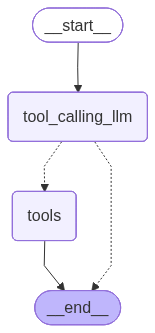

In [3]:
from IPython.display import Image, display
from langgraph.graph import (
    StateGraph, 
    START, 
    END,
    MessagesState,
)
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
print(messages['messages'])
for m in messages['messages']:
    m.pretty_print()

print("=========no tool call=============")
messages = graph.invoke({"messages": "你好~"})
print(messages['messages'])
for m in messages['messages']:
    m.pretty_print()

[HumanMessage(content='Hello, what is 2 multiplied by 2?', additional_kwargs={}, response_metadata={}, id='815ace57-0d5b-4794-aa6c-b65038945a4b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_7cd6224596644b51907258', 'function': {'arguments': '{"a": 2, "b": 2}', 'name': 'multiply'}, 'type': 'function', 'index': 0}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 192, 'total_tokens': 214, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'qwen-max', 'system_fingerprint': None, 'id': 'chatcmpl-aea759cd-a41e-4dcf-a9f6-55c6cbd94ebf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-b74db868-4e48-404a-a01d-b6d57b80381a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'call_7cd6224596644b51907258', 'type': 'tool_call'}], usage_metadata={'input_tokens': 192, 'output_tokens': 22, 'total_tokens': 214, 'input_token_details': {'c